<a href="https://colab.research.google.com/github/tamara-kostova/MSc_Thesis_Neuroimaging/blob/master/13_SAM3_Tumor_dataset_BraTS2021_125_intersection_all_slices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from google.colab import userdata
import os
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [3]:
import os
os.makedirs("/content/drive/MyDrive/SAM 3/brats2021", exist_ok=True)

In [4]:
!kaggle datasets download \
  -d dschettler8845/brats-2021-task1 \
  -f BraTS2021_Training_Data.tar \
  -p /content --force

Dataset URL: https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1
License(s): copyright-authors
^C


In [4]:
!ls "/content/drive/MyDrive/SAM 3/brats2021"

BraTS2021_Training_Data.tar  plots


In [6]:
!mkdir -p /content/brats2021
!tar -xf "/content/drive/MyDrive/SAM 3/brats2021/BraTS2021_Training_Data.tar" -C /content/brats2021/

tar: Unexpected EOF in archive
tar: rmtlseek not stopped at a record boundary
tar: Error is not recoverable: exiting now


In [5]:
import numpy as np
import nibabel as nib
from PIL import Image
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import torch
import gc

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [6]:
def load_brats21_case(case_dir):
    """Load BraTS21 - handles both .nii and .nii.gz files."""

    # Try both extensions
    files = list(case_dir.glob("*.nii.gz")) + list(case_dir.glob("*.nii"))

    t1ce = seg = None

    for f in files:
        name_lower = f.name.lower()

        if 'seg' in name_lower:
            seg = nib.load(f).get_fdata()
        elif 't1ce' in name_lower:
            t1ce = nib.load(f).get_fdata()

    return t1ce, seg

In [7]:
def normalize_mri(img):
    img_min, img_max = img.min(), img.max()
    return (img - img_min) / (img_max - img_min + 1e-8)

In [8]:
def compute_metrics(pred, gt):
    """Calculate segmentation metrics."""
    pred_flat = pred.flatten() > 0.5
    gt_flat = gt.flatten() > 0.5
    tp = np.sum(pred_flat & gt_flat)
    fp = np.sum(pred_flat & ~gt_flat)
    fn = np.sum(~pred_flat & gt_flat)
    dice = 2 * tp / (2 * tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {'dice': dice, 'iou': iou, 'sensitivity': sens, 'tp': tp, 'fp': fp, 'fn': fn}

In [9]:
_debug_printed = False

def safe_sam3_inference(processor, img, prompt):
    """Safe SAM3 inference with correct API."""
    global _debug_printed
    try:
        if img.mode != 'RGB':
            img = img.convert('RGB')

        inference_state = processor.set_image(img)

        processor.reset_all_prompts(inference_state)
        output = processor.set_text_prompt(state=inference_state, prompt=prompt)

        if not _debug_printed:
            print(f"[DEBUG] output keys: {list(output.keys())}")
            for k, v in output.items():
                try:
                    print(f"  {k}: type={type(v)}, shape/len={getattr(v, 'shape', None) or len(v)}")
                except:
                    print(f"  {k}: {v}")
            _debug_printed = True

        masks = output.get("masks", torch.tensor([]))
        scores = output.get("scores", torch.tensor([]))

        if len(masks) == 0 or len(scores) == 0:
            return None, 0.0, 0

        best_idx = torch.argmax(scores)
        best_mask = masks[best_idx].cpu().numpy().squeeze()
        best_score = scores[best_idx].item()

        torch.cuda.empty_cache()

        return best_mask, best_score, len(masks)
    except Exception as e:
        print(f"    ⚠️  SAM3 error: {e}")
        import traceback; traceback.print_exc()
        torch.cuda.empty_cache()
        return None, 0.0, 0


In [10]:
def plot_brats_comparison(t1ce_slice, gt_mask, sam3_mask, scores, case_name, slice_idx, dice, save_path):
    """4-panel BraTS visualization."""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. T1-contrast input
    axes[0,0].imshow(t1ce_slice, cmap='gray')
    axes[0,0].set_title(f'{case_name} slice {slice_idx}\nT1-Contrast Enhanced Input',
                       fontsize=12, fontweight='bold')
    axes[0,0].axis('off')

    # 2. Ground Truth
    axes[0,1].imshow(gt_mask, cmap='Reds', alpha=0.8, vmin=0, vmax=1)
    axes[0,1].set_title(f'Expert Ground Truth\nTumor voxels: {gt_mask.sum():,.0f}',
                       fontsize=12, fontweight='bold')
    axes[0,1].axis('off')

    # 3. SAM3 Prediction
    axes[1,0].imshow(sam3_mask > 0.5, cmap='Greens', alpha=0.8)
    axes[1,0].set_title(f'SAM3 Prediction\nScore: {scores:.3f} | Voxels: {(sam3_mask > 0.5).sum():,.0f}',
                       fontsize=12, fontweight='bold')
    axes[1,0].axis('off')

    # 4. Overlay
    overlay = np.stack([t1ce_slice, t1ce_slice, t1ce_slice], axis=-1)

    # Red for GT, Green for SAM3
    overlay[gt_mask > 0, 0] = 1.0  # Red channel
    overlay[sam3_mask > 0.5, 1] = 1.0  # Green channel

    axes[1,1].imshow(overlay)
    axes[1,1].set_title(f'OVERLAY: Red=GT | Green=SAM3\nDice: {dice:.3f}',
                       fontsize=14, fontweight='bold', pad=20)
    axes[1,1].axis('off')

    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

    return dice


In [11]:
# ── Patient list ─────────────────────────────────────────────────────────────
patients_list_file = '/content/drive/MyDrive/MSc_Thesis_Neuroimaging/patients.txt'
with open(patients_list_file) as f:
    PATIENT_IDS = [line.strip() for line in f if line.strip()]
print(f'Total patients: {len(PATIENT_IDS)}')

Total patients: 125


In [8]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e ".[notebooks]"  > /dev/null
%cd /content

!pip install -q supervision jupyter_bbox_widget  > /dev/null

Cloning into 'sam3'...
remote: Enumerating objects: 921, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 921 (delta 8), reused 3 (delta 3), pack-reused 904 (from 2)
Receiving objects: 100% (921/921), 59.48 MiB | 48.34 MiB/s, done.
Resolving deltas: 100% (186/186), done.
/content/sam3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is inco

In [9]:
!pip install triton decord  > /dev/null

In [13]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

In [14]:
import sam3
from sam3.sam3 import build_sam3_image_model
import os
# sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")
bpe_path = f"/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"

In [17]:
from sam3.model.sam3_image_processor import Sam3Processor
model = build_sam3_image_model(bpe_path=bpe_path)
processor = Sam3Processor(model, confidence_threshold=0.0)
_debug_printed = False

In [18]:
PROMPT     = 'brain tumor'
BRATS_PATH = Path('/content/brats2021')
OUT_DIR    = Path('/content/drive/MyDrive/SAM 3/brats2021')
OUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_CSV = OUT_DIR / 'brats21_results_checkpoint.csv'

completed_cases = set()
if CHECKPOINT_CSV.exists():
    prev_df = pd.read_csv(CHECKPOINT_CSV)
    completed_cases = set(prev_df['case'].unique())
    print(f'Resuming — {len(completed_cases)} patients already in checkpoint.')
else:
    print('Starting fresh.')

remaining = [pid for pid in PATIENT_IDS
             if pid not in completed_cases
             and (BRATS_PATH / pid).exists()]
print(f'Patients to process: {len(remaining)}')

for case_name in tqdm(remaining, desc='Patients'):
    case_dir = BRATS_PATH / case_name
    t1ce, seg = load_brats21_case(case_dir)
    if t1ce is None or seg is None:
        tqdm.write(f'  Skipping {case_name}: failed to load')
        continue

    tumor_slices = [i for i in range(seg.shape[2]) if (seg[:, :, i] > 0).any()]
    case_results = []

    for slice_idx in tqdm(tumor_slices, desc=f'  {case_name}', leave=False):
        gt_slice  = seg[:, :, slice_idx] > 0
        t1ce_norm = normalize_mri(t1ce[:, :, slice_idx])
        t1ce_rgb  = (np.repeat(t1ce_norm[:, :, np.newaxis], 3, axis=2) * 255).astype(np.uint8)
        img       = Image.fromarray(t1ce_rgb)

        pred_mask, score, n_masks = safe_sam3_inference(processor, img, PROMPT)
        if pred_mask is None:
            pred_mask = np.zeros_like(gt_slice, dtype=np.float32)
            score = 0.0

        metrics = compute_metrics(pred_mask, gt_slice)
        metrics.update({
            'case':        case_name,
            'slice':       slice_idx,
            'score':       score,
            'prompt':      PROMPT,
            'gt_voxels':   int(gt_slice.sum()),
            'pred_voxels': int((pred_mask > 0.5).sum()),
        })
        case_results.append(metrics)

        del img, t1ce_rgb, t1ce_norm, pred_mask
        gc.collect()

    if case_results:
        case_df = pd.DataFrame(case_results)
        header  = not CHECKPOINT_CSV.exists()
        case_df.to_csv(CHECKPOINT_CSV, mode='a', index=False, header=header)
        mean_dice = case_df['dice'].mean()
        n_empty   = (case_df['pred_voxels'] == 0).sum()
        tqdm.write(f'  {case_name}: {len(case_results)} slices | mean Dice={mean_dice:.3f} | empty={n_empty}')

    del t1ce, seg
    gc.collect()
    torch.cuda.empty_cache()

print('\n✅ Evaluation loop complete.')

Starting fresh.
Patients to process: 125


  BraTS2021_00000:   0%|          | 0/47 [00:00<?, ?it/s]

[DEBUG] output keys: ['original_height', 'original_width', 'backbone_out', 'geometric_prompt', 'masks_logits', 'masks', 'boxes', 'scores']
  original_height: 240
  original_width: 240
  backbone_out: type=<class 'dict'>, shape/len=7
  geometric_prompt: <sam3.model.geometry_encoders.Prompt object at 0x7e89e2c05c70>
  masks_logits: type=<class 'torch.Tensor'>, shape/len=torch.Size([200, 1, 240, 240])
  masks: type=<class 'torch.Tensor'>, shape/len=torch.Size([200, 1, 240, 240])
  boxes: type=<class 'torch.Tensor'>, shape/len=torch.Size([200, 4])
  scores: type=<class 'torch.Tensor'>, shape/len=torch.Size([200])



Patients:   0%|          | 0/125 [01:40<?, ?it/s]

  BraTS2021_00000: 47 slices | mean Dice=0.217 | empty=0


...

  BraTS2021_00519: 60 slices | mean Dice=0.086 | empty=0


Patients:  99%|█████████▉| 124/125 [5:31:11<02:34, 154.63s/it]

  BraTS2021_00520: 46 slices | mean Dice=0.086 | empty=0


Patients: 100%|██████████| 125/125 [5:31:11<00:00, 158.97s/it]


✅ Evaluation loop complete.


In [19]:
from scipy import stats

results_df = pd.read_csv(CHECKPOINT_CSV)
print(f'Total slices: {len(results_df)} across {results_df["case"].nunique()} cases')

n_empty = (results_df['pred_voxels'] == 0).sum()
print(f'Empty predictions: {n_empty} ({100*n_empty/len(results_df):.1f}%)')
print()

summary_rows = []
for metric in ['dice', 'iou', 'sensitivity']:
    vals = results_df[metric]
    mean = vals.mean()
    se   = stats.sem(vals)
    ci_low, ci_high = stats.t.interval(0.95, df=len(vals)-1, loc=mean, scale=se)
    summary_rows.append({'metric': metric, 'mean': round(mean,4),
                         'ci_low': round(ci_low,4), 'ci_high': round(ci_high,4),
                         'n': len(vals)})
    print(f'  {metric.capitalize():12s}  {mean:.4f}   95% CI [{ci_low:.4f}, {ci_high:.4f}]')

summary_df = pd.DataFrame(summary_rows)
summary_csv = OUT_DIR / 'brats21_summary_ci.csv'
summary_df.to_csv(summary_csv, index=False)

final_csv = OUT_DIR / 'brats21_results_final.csv'
results_df.to_csv(final_csv, index=False)
print(f'\n✅ Results saved to: {final_csv}')
print(f'✅ Summary saved to: {summary_csv}')

Total slices: 8196 across 125 cases
Empty predictions: 0 (0.0%)

  Dice          0.1886   95% CI [0.1840, 0.1932]
  Iou           0.1240   95% CI [0.1202, 0.1277]
  Sensitivity   0.3969   95% CI [0.3886, 0.4051]

✅ Results saved to: /content/drive/MyDrive/SAM 3/brats2021/brats21_results_final.csv
✅ Summary saved to: /content/drive/MyDrive/SAM 3/brats2021/brats21_summary_ci.csv


Generating 20 plots...


100%|██████████| 20/20 [01:04<00:00,  3.22s/it]


✅ 20 plots saved to /content/drive/MyDrive/SAM 3/brats2021/plots


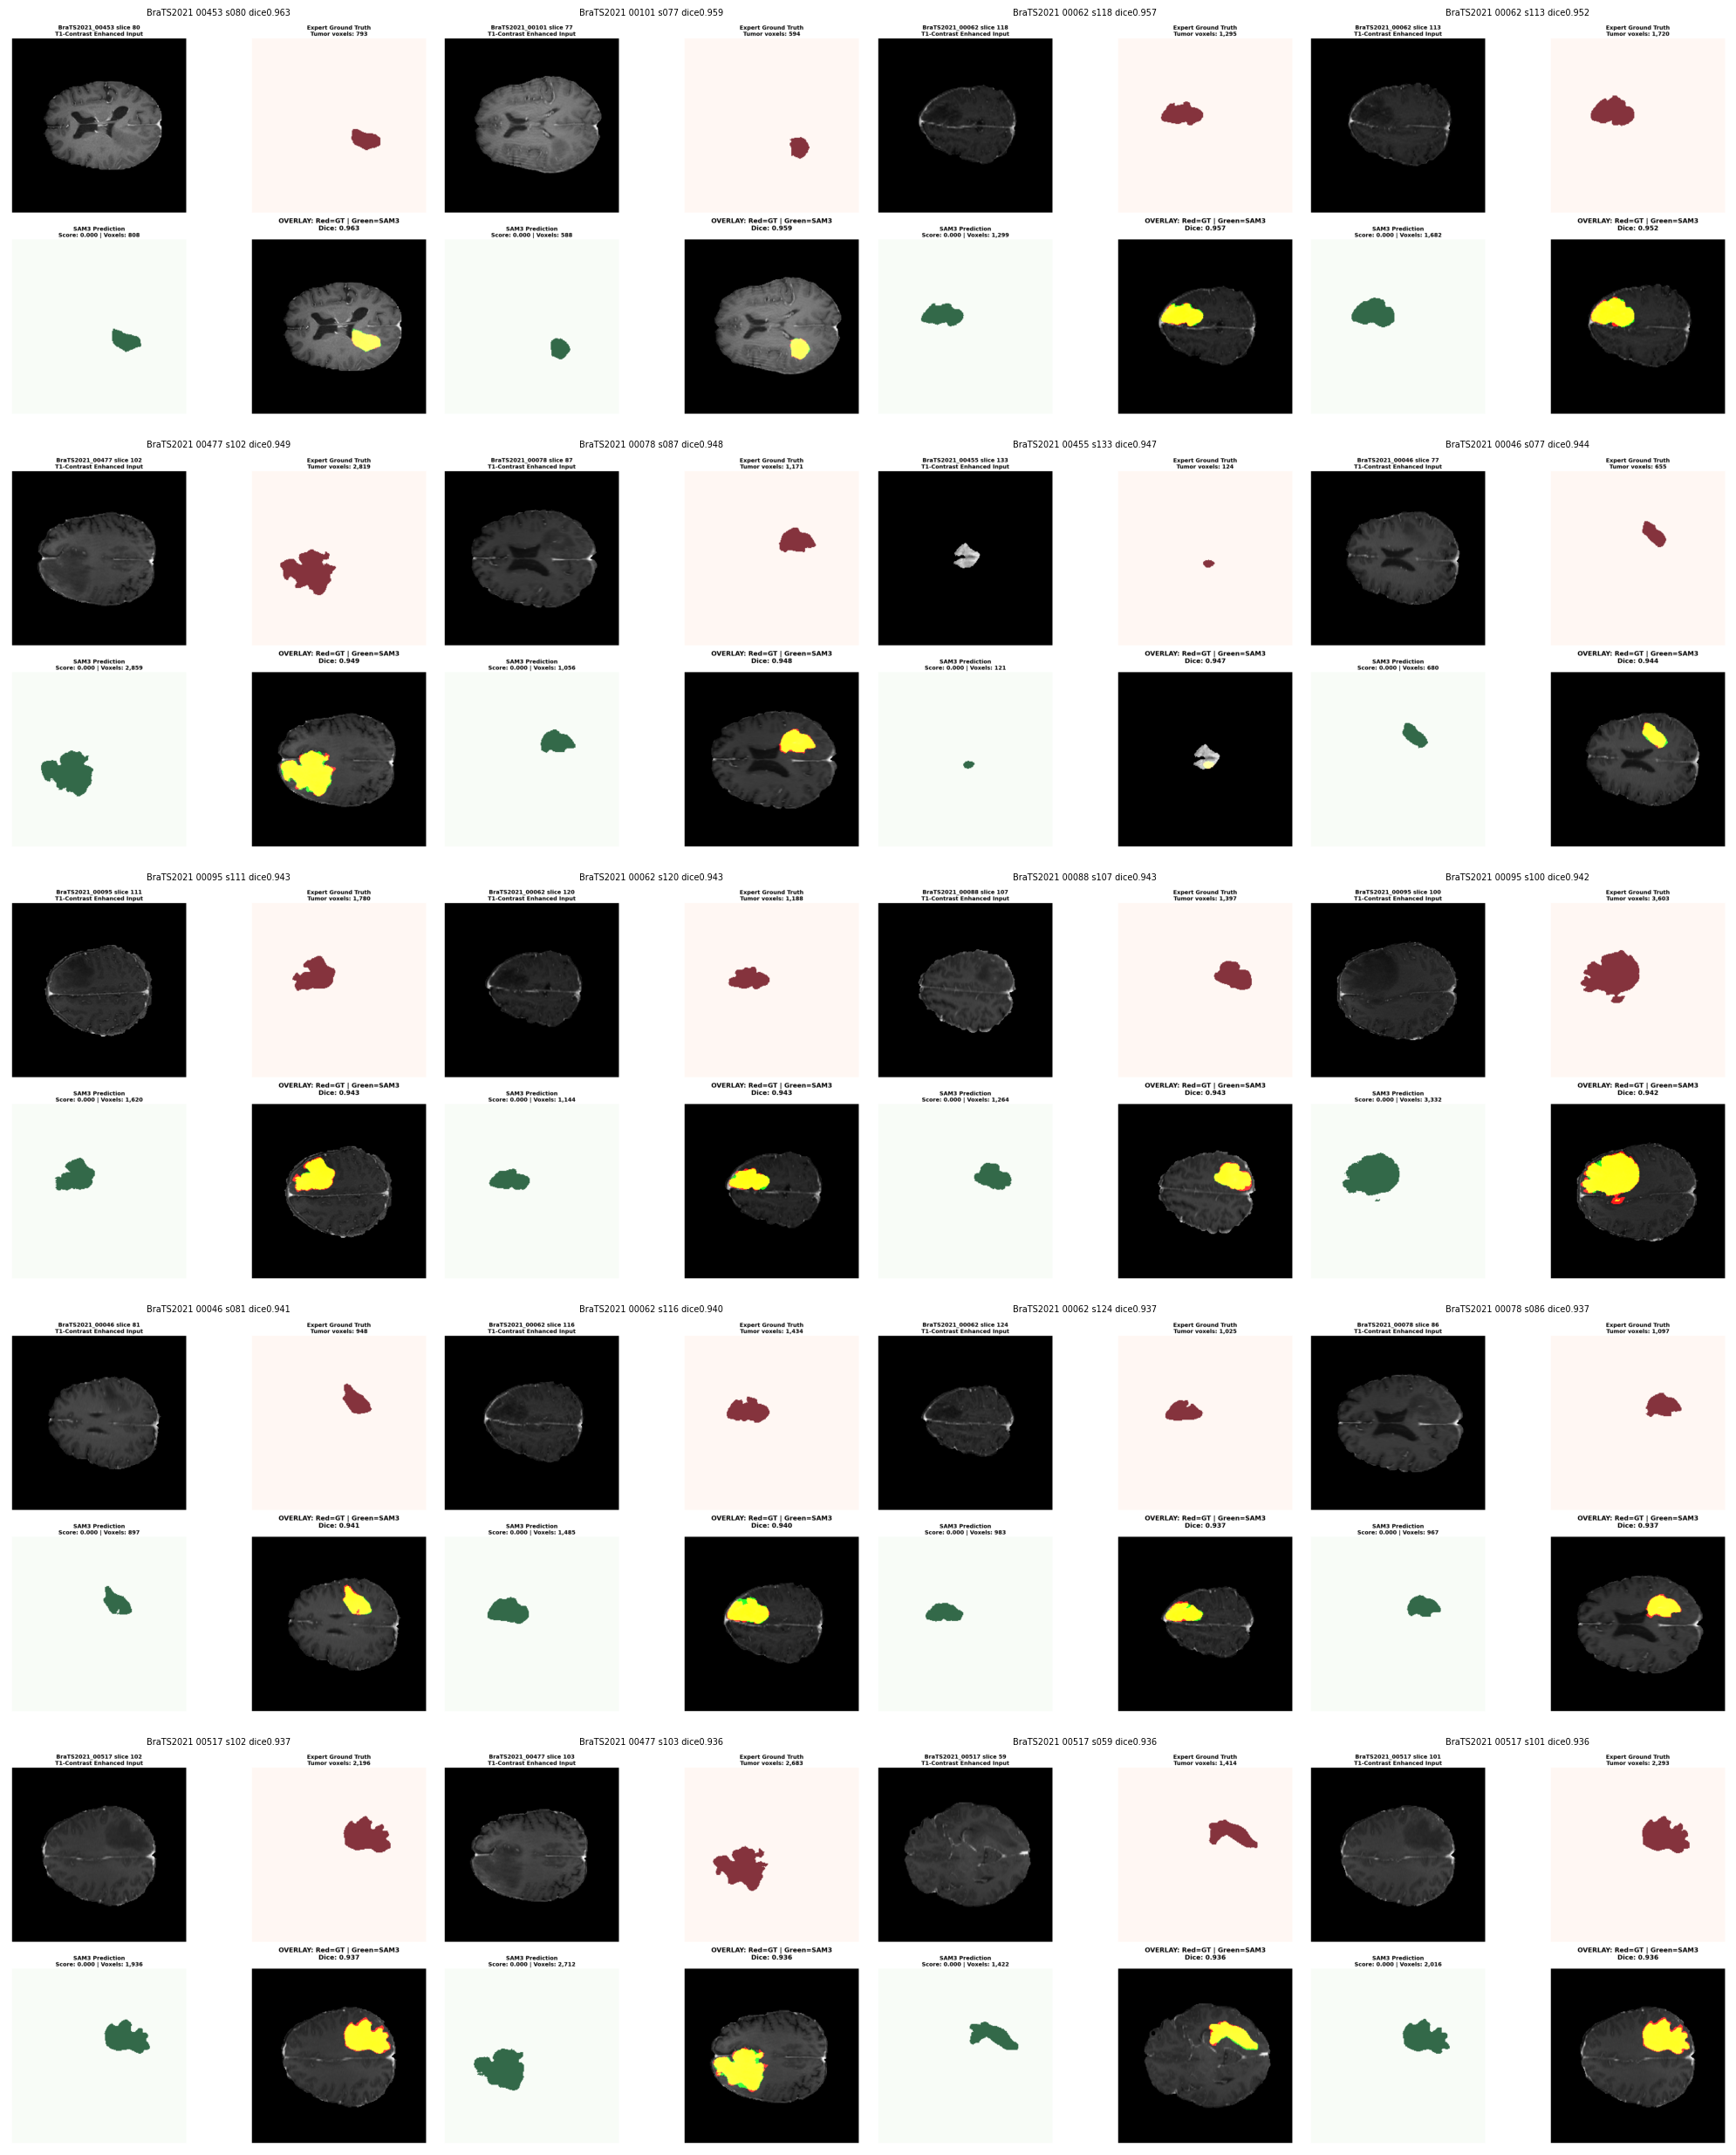

✅ Gallery saved: /content/drive/MyDrive/SAM 3/brats2021/brats_gallery.png


In [20]:
def plot_brats_comparison(t1ce_slice, gt_mask, sam3_mask, score, case_name, slice_idx, dice, save_path):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes[0,0].imshow(t1ce_slice, cmap='gray')
    axes[0,0].set_title(f'{case_name} slice {slice_idx}\nT1-Contrast Enhanced Input',
                        fontsize=12, fontweight='bold')
    axes[0,0].axis('off')
    axes[0,1].imshow(gt_mask, cmap='Reds', alpha=0.8, vmin=0, vmax=1)
    axes[0,1].set_title(f'Expert Ground Truth\nTumor voxels: {gt_mask.sum():,.0f}',
                        fontsize=12, fontweight='bold')
    axes[0,1].axis('off')
    axes[1,0].imshow(sam3_mask > 0.5, cmap='Greens', alpha=0.8)
    axes[1,0].set_title(f'SAM3 Prediction\nScore: {score:.3f} | Voxels: {(sam3_mask>0.5).sum():,.0f}',
                        fontsize=12, fontweight='bold')
    axes[1,0].axis('off')
    overlay = np.stack([t1ce_slice]*3, axis=-1)
    overlay[gt_mask > 0, 0] = 1.0
    overlay[sam3_mask > 0.5, 1] = 1.0
    axes[1,1].imshow(overlay)
    axes[1,1].set_title(f'OVERLAY: Red=GT | Green=SAM3\nDice: {dice:.3f}',
                        fontsize=14, fontweight='bold', pad=20)
    axes[1,1].axis('off')
    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

MAX_PLOTS = 20
PLOT_DIR  = OUT_DIR / 'plots'
PLOT_DIR.mkdir(exist_ok=True)

top_slices = results_df[results_df['dice'] > 0].nlargest(MAX_PLOTS, 'dice')
print(f'Generating {len(top_slices)} plots...')

plot_paths = []
for _, row in tqdm(top_slices.iterrows(), total=len(top_slices)):
    case_dir  = BRATS_PATH / row['case']
    t1ce, seg = load_brats21_case(case_dir)
    if t1ce is None:
        continue
    si = int(row['slice'])
    t1ce_norm = normalize_mri(t1ce[:, :, si])
    gt_mask   = seg[:, :, si] > 0

    t1ce_rgb   = (np.repeat(t1ce_norm[:,:,np.newaxis], 3, axis=2) * 255).astype(np.uint8)
    img        = Image.fromarray(t1ce_rgb)
    pred_mask, score, _ = safe_sam3_inference(processor, img, PROMPT)
    if pred_mask is None:
        pred_mask = np.zeros_like(gt_mask, dtype=np.float32)

    filename   = f"{row['case']}_s{si:03d}_dice{row['dice']:.3f}.png"
    plot_path  = PLOT_DIR / filename
    plot_brats_comparison(t1ce_norm, gt_mask, pred_mask,
                          score, row['case'], si, row['dice'], plot_path)
    plot_paths.append(plot_path)
    del t1ce, seg, img, t1ce_rgb

print(f'✅ {len(plot_paths)} plots saved to {PLOT_DIR}')

# Gallery
n_plots = len(plot_paths)
if n_plots > 0:
    cols = 4
    rows = (n_plots + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
    axes = np.array(axes).flatten()
    for i, p in enumerate(plot_paths):
        axes[i].imshow(plt.imread(p))
        axes[i].set_title(Path(p).stem.replace('_', ' '), fontsize=7)
        axes[i].axis('off')
    for i in range(n_plots, len(axes)):
        axes[i].axis('off')
    plt.tight_layout()
    gallery_path = OUT_DIR / 'brats_gallery.png'
    plt.savefig(gallery_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'✅ Gallery saved: {gallery_path}')